# Learning a Decision Tree Classifier

In this notebook, we will train a binary decision tree classifier.

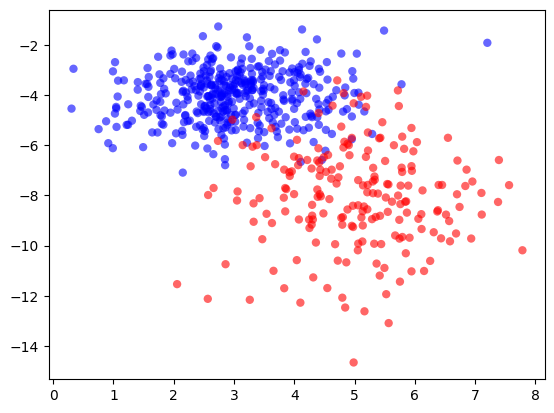

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.random.seed(46)

size_1, size_2 = 400, 200

xs = np.concatenate([np.random.randn(size_1) + 3, np.random.randn(size_2) + 5])
ys = np.concatenate([np.random.randn(size_1) - 4, np.random.randn(size_2)*2 - 8])
zs = np.concatenate([[0] * size_1, [1] * size_2])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def predict(wx, wy, b):
    return sigmoid(wx * xs + wy * ys + b)

def cross_entropy(zs, zhats):
    return -np.sum(zs * np.log(zhats) + (1 - zs) * np.log(1 - zhats))

plt.scatter(xs, ys, c=zs, cmap='bwr', alpha=0.6, edgecolors='none')

In [2]:
data = np.stack([xs, ys, zs]).T
data[:3]

array([[ 3.58487584, -4.92837948,  0.        ],
       [ 4.23119574, -3.32268834,  0.        ],
       [ 3.82190026, -4.18499184,  0.        ]])

In [3]:
def train_test_split(
    data: np.ndarray,
    test_proportion: float = 0.2
) -> tuple[np.ndarray, np.ndarray]:
    assert(test_proportion <= 1.0 and test_proportion >= 0)

    data_copy = np.copy(data)
    np.random.shuffle(data_copy)
    test_count = round(len(data) * test_proportion)

    train_split = data_copy[test_count:]
    test_split = data_copy[:test_count]
    return train_split, test_split

[len(x) for x in train_test_split(data)]

[480, 120]

In [4]:
def feature_indices_of(array: np.ndarray) -> range:
    return range(array.shape[1] - 1)

[*feature_indices_of(data)]

[0, 1]

In [40]:
def target_column_of(array: np.ndarray) -> np.ndarray:
    return array[:, array.shape[1] - 1]

target_column_of(data)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

Gini impurity:

$$
I_G = 1 - \sum_{i=1}^n p_i^2
$$

In [6]:
def gini_impurity(data: np.ndarray) -> np.float:
    if len(data) == 0:
        return 0.0

    counts = np.unique_counts(target_column_of(data)).counts
    
    return 1 - np.sum(
        (counts / len(data)) ** 2
    )

gini_impurity(data)

np.float64(0.4444444444444444)

In [45]:
def frequency(target, samples):
    if len(samples) == 0:
        return 0.0

    uc = np.unique_counts(target_column_of(samples))
    if target in uc.values:
        d = list(uc.values).index(target)
        r = uc.counts[d] / len(samples)
        return r
    else:
        return 0.0

frequency(0.0, data)

np.float64(0.6666666666666666)


How to build a decision tree? Recursive algorithm
- If we hit minimum number of samples, or maximum depth, or impurity of data is zero, return a leaf node
- For each **variable** (feature), for each possible **split** of a variable:
	- Find the maximum impurity reduction (aka information gain) $\Delta i(s,t)$
		- $p_L$- proportion of left node cases (could also be called weights by some)
			- for example, I have 800 cases, 200 of them I put in the left node, therefore $p_L = 800/200 = 4$
		- $p_R$ - proportion of right node cases
		- $i(t), i: \text{Node} \to \mathbb{R}$ - [[impurity function]] of a node, where node's value is a set of cases
		- information gain ($t$ - current node, $t_L$ - left child node, $t_R$ - right child node):
$$
\Delta i(s, t) = i(t) - p_Li(t_L) - p_Ri(t_R)
$$
- (contd)
	- Use the split with the maximum impurity reduction, continue recursively in each child


In [8]:
def filter_rows(array, fun):
    return array[
        np.apply_along_axis(
            fun,
            axis=1,
            arr=array
        )
    ]

filter_rows(data, lambda row: row[0] < 1.2)

array([[ 0.30579542, -4.54580378,  0.        ],
       [ 1.07785288, -3.43125342,  0.        ],
       [ 0.99295301, -3.06164964,  0.        ],
       [ 1.0276829 , -2.69523009,  0.        ],
       [ 1.0257914 , -4.74306174,  0.        ],
       [ 1.04604127, -4.47825436,  0.        ],
       [ 1.17443386, -3.41886506,  0.        ],
       [ 1.05249744, -5.27508491,  0.        ],
       [ 0.91542933, -5.92300859,  0.        ],
       [ 0.99105233, -6.12197536,  0.        ],
       [ 1.04745131, -4.53659867,  0.        ],
       [ 0.87957373, -5.05025636,  0.        ],
       [ 0.75491009, -5.36284947,  0.        ],
       [ 1.07088586, -4.06483964,  0.        ],
       [ 0.33825236, -2.95858128,  0.        ]])

In [9]:
def splits_of(samples, feature_idx):
    for threshold in np.unique(samples[:, feature_idx]):
        l_cases = filter_rows(samples, lambda row: row[feature_idx] <= threshold)
        r_cases = filter_rows(samples, lambda row: row[feature_idx]  > threshold)
        yield l_cases, r_cases, threshold

# Uncomment to try it out:
# [*splits_of(data, 0)][7]

In [10]:
from dataclasses import dataclass

@dataclass
class ValueNode:
    one_probability: float

    def classify(self, sample):
        return self.one_probability

@dataclass
class DecisionNode:
    left: ValueNode | DecisionNode
    right: ValueNode | DecisionNode
    feature_idx: int
    treshold: float

    def classify(self, sample):
        if sample[self.feature_idx] <= self.treshold:
            return self.left.classify(sample)
        else:
            return self.right.classify(sample)

In [11]:
import time

class MeasureExecutionTime:
    def __init__(self, title: str):
        self.title = title
        self.t1 = -1
        self.t2 = -1

    def __enter__(self):
        self.t1 = time.perf_counter()

    def __exit__(self, exc_type, exc_val, exc_traceback):
        self.t2 = time.perf_counter()
        print(f"Task {self.title} took {self.t2 - self.t1} seconds")

In [46]:
from typing import Callable

def build_decision_tree(
    samples: np.array,
    *,
    impurity: Callable[[np.ndarray], np.float],
    min_samples: int = 1,
    max_depth: int = 10,
):
    current_impurity = impurity(samples)
    samples_count = len(samples)

    def value_node():
        return ValueNode(frequency(1.0, samples))

    if (
        samples_count < min_samples
        or impurity(samples) == 0.0
        or max_depth <= 1
    ):
        return value_node()

    max_information_gain = float("-inf")
    best_l_cases = None
    best_treshold = None
    best_feature_idx = None
    best_r_cases = None

    for feature_idx in feature_indices_of(data):
        for (l_cases, r_cases, treshold) in splits_of(samples, feature_idx):
            information_gain = (
                current_impurity
                - len(l_cases) * impurity(l_cases) / samples_count
                - len(r_cases) * impurity(r_cases) / samples_count
            )

            if information_gain > max_information_gain:
                max_information_gain = information_gain
                best_l_cases = l_cases
                best_r_cases = r_cases
                best_treshold = treshold
                best_feature_idx = feature_idx

    if best_l_cases is not None:
        return DecisionNode(
            left=build_decision_tree(
                best_l_cases,
                impurity=impurity,
                min_samples=min_samples,
                max_depth=max_depth - 1
            ),
            right=build_decision_tree(
                best_r_cases,
                impurity=impurity,
                min_samples=min_samples,
                max_depth=max_depth - 1
            ),
            feature_idx=best_feature_idx,
            treshold=best_treshold,
        )

    # If all else fails
    return value_node()

train_data, test_data = train_test_split(data)

with MeasureExecutionTime("Build a decision tree"):
    decision_tree = build_decision_tree(
        train_data,
        impurity=gini_impurity,
        min_samples=1,
        max_depth=4,
    )

decision_tree

Task Build a decision tree took 0.9996721670031548 seconds


DecisionNode(left=DecisionNode(left=DecisionNode(left=ValueNode(one_probability=np.float64(0.6666666666666666)), right=ValueNode(one_probability=np.float64(1.0)), feature_idx=0, treshold=np.float64(2.853385011740216)), right=DecisionNode(left=ValueNode(one_probability=np.float64(0.21428571428571427)), right=ValueNode(one_probability=np.float64(0.8181818181818182)), feature_idx=0, treshold=np.float64(3.929617554853914)), feature_idx=1, treshold=np.float64(-6.592673563005676)), right=DecisionNode(left=DecisionNode(left=ValueNode(one_probability=np.float64(0.0037174721189591076)), right=ValueNode(one_probability=np.float64(0.07142857142857142)), feature_idx=0, treshold=np.float64(4.134431705542565)), right=DecisionNode(left=ValueNode(one_probability=np.float64(0.625)), right=ValueNode(one_probability=np.float64(0.125)), feature_idx=1, treshold=np.float64(-3.8213653465934545)), feature_idx=0, treshold=np.float64(4.623757119193883)), feature_idx=1, treshold=np.float64(-5.662511569885875))

In [77]:
predictions = []
for datum in test_data:
    predictions.append(
        1.0
        if decision_tree.classify(datum) > 0.5
        else 0.0
    )

# https://stackoverflow.com/a/28663910
unique, counts = np.unique(target_column_of(test_data) == predictions, return_counts=True)
accuracy = dict(zip(unique, counts))[True] / len(test_data)
print(f"Test accuracy: {accuracy*100:.2f}%")

Test accuracy: 91.67%


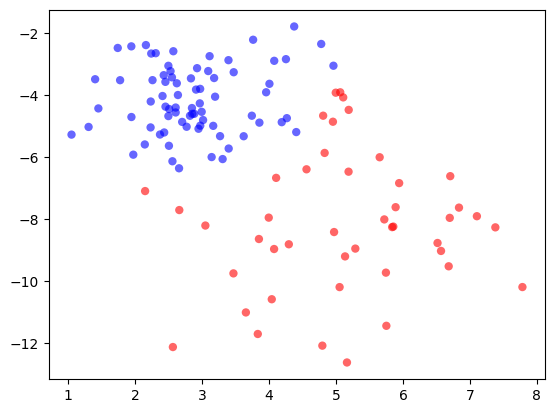

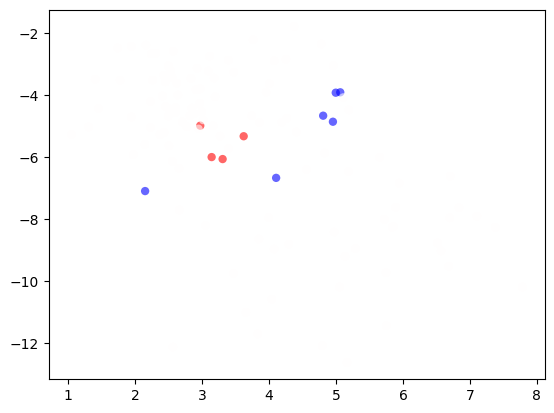

In [79]:
plt.scatter(test_data[:, 0], test_data[:, 1], c=predictions, cmap='bwr', alpha=0.6, edgecolors='none')
plt.show()

plt.scatter(test_data[:, 0], test_data[:, 1], c=test_data[:, 2] - predictions, cmap='bwr', alpha=0.6, edgecolors='none')

In [15]:
decision_tree.classify([2.6, -10])

np.float64(0.42105263157894735)